In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


In [ ]:
print("Loading Dataset...")
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X=mnist.data
y=mnist.target

Loading Dataset...


In [ ]:
X.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
def show_digits(data,labels,n_samples=10):
  """Display Sample digits from dataset"""
  fig,axes=plt.subplots(2,5,figsize=(12,6))
  axes=axes.ravel()

  for i in range(n_samples):
    image=data[i].reshape(28,28)
    axes[i].imshow(image,cmap='gray')
    axes[i].set_title(f"label : {labels[i]}")
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()


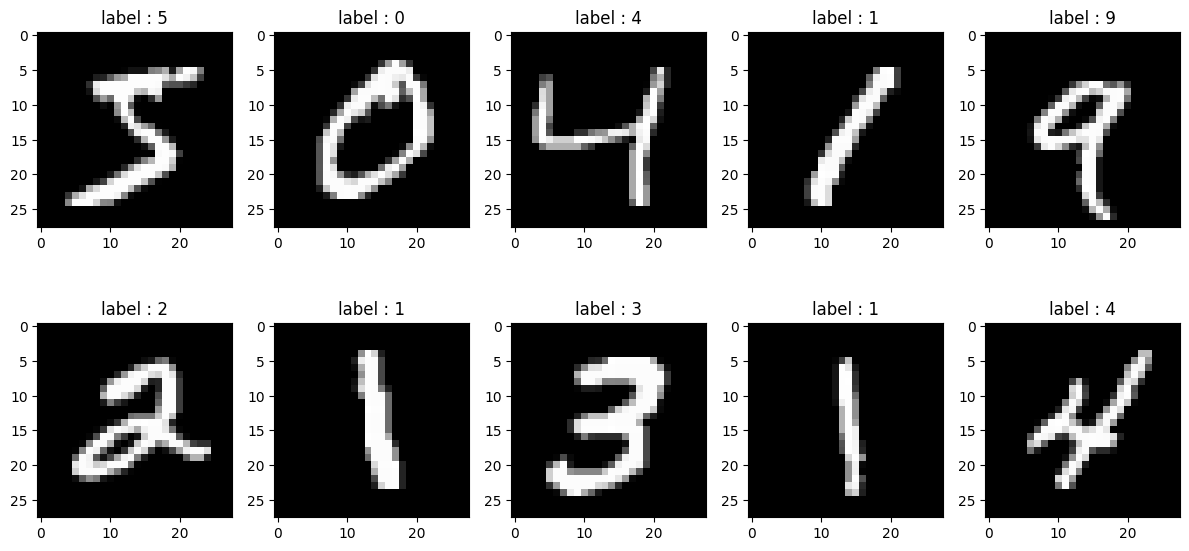

In [25]:
show_digits(X.values,y)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

In [ ]:
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")



Training samples: 56000
Test samples: 14000


In [27]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("\nData scaled successfully!")



Data scaled successfully!


In [28]:
print("Training Logistic Regression Model : ")
model=LogisticRegression(
    max_iter=100,
    solver='saga',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

Training Logistic Regression Model : 


In [29]:
model.fit(X_train,y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 235 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(n_jobs=-1, random_state=42, solver='saga', verbose=1)

In [ ]:
print("Making Predictions...")
y_pred_train=model.predict(X_train_scaled)
y_pred_test=model.predict(X_test_scaled)

Making Predictions...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 75.20%
Test Accuracy: 73.46%



CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1381
           1       0.50      0.99      0.67      1575
           2       0.85      0.65      0.74      1398
           3       0.87      0.53      0.65      1428
           4       0.77      0.85      0.81      1365
           5       0.75      0.58      0.66      1263
           6       0.85      0.92      0.88      1375
           7       0.71      0.94      0.81      1459
           8       0.94      0.21      0.34      1365
           9       0.80      0.66      0.72      1391

    accuracy                           0.73     14000
   macro avg       0.79      0.73      0.72     14000
weighted avg       0.78      0.73      0.72     14000



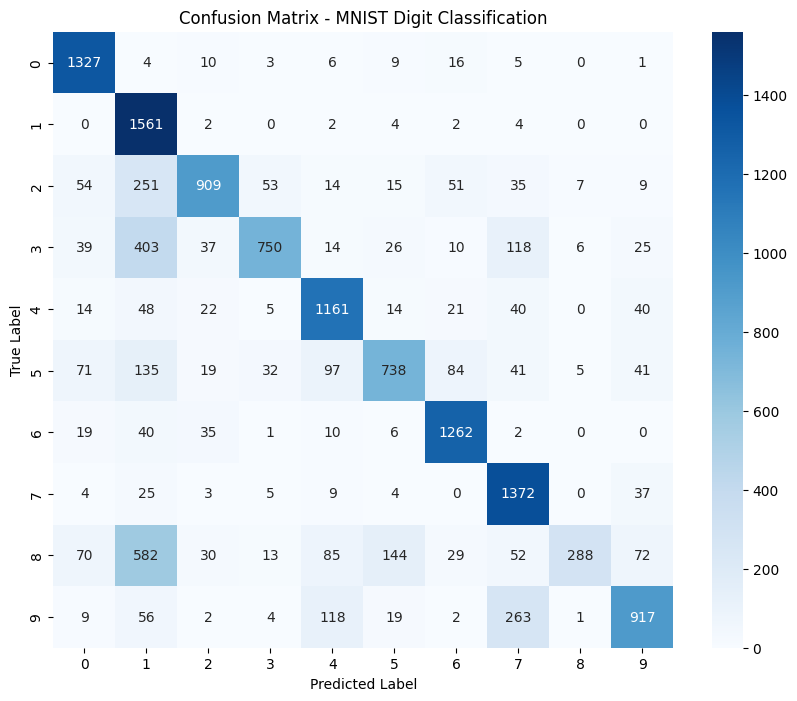


SAMPLE PREDICTIONS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


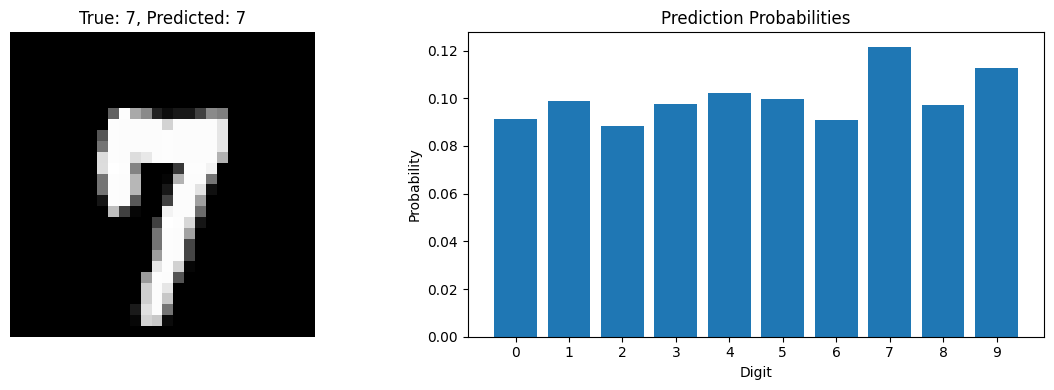


Sample 2900:
  True Label: 7
  Predicted: 7
  Confidence: 12.16%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


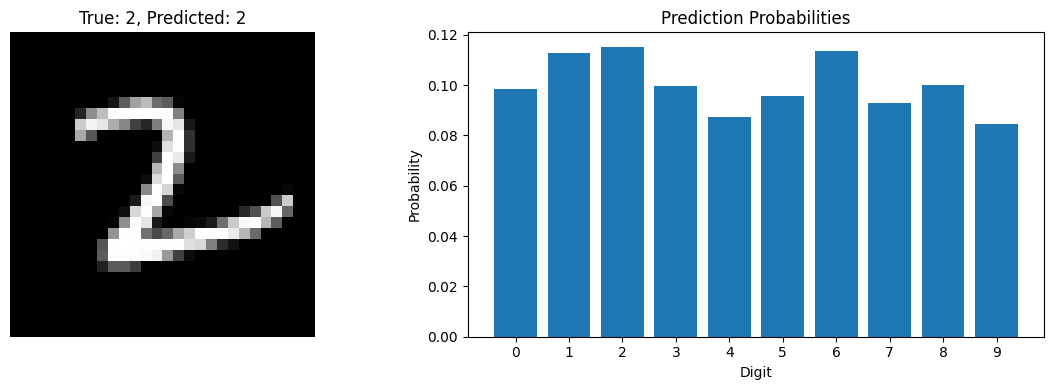


Sample 3143:
  True Label: 2
  Predicted: 2
  Confidence: 11.52%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


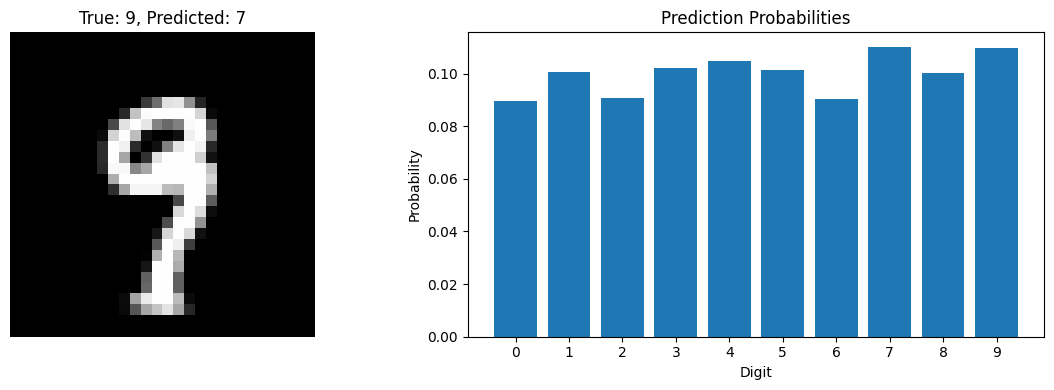


Sample 8231:
  True Label: 9
  Predicted: 7
  Confidence: 11.02%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


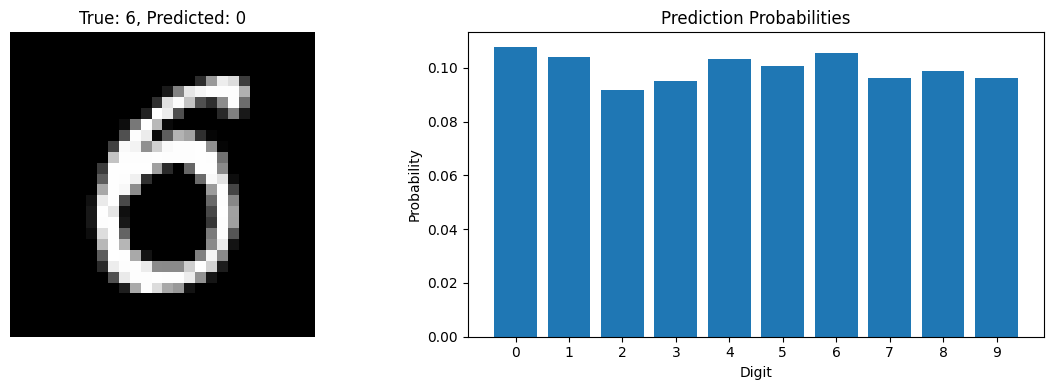


Sample 3855:
  True Label: 6
  Predicted: 0
  Confidence: 10.79%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


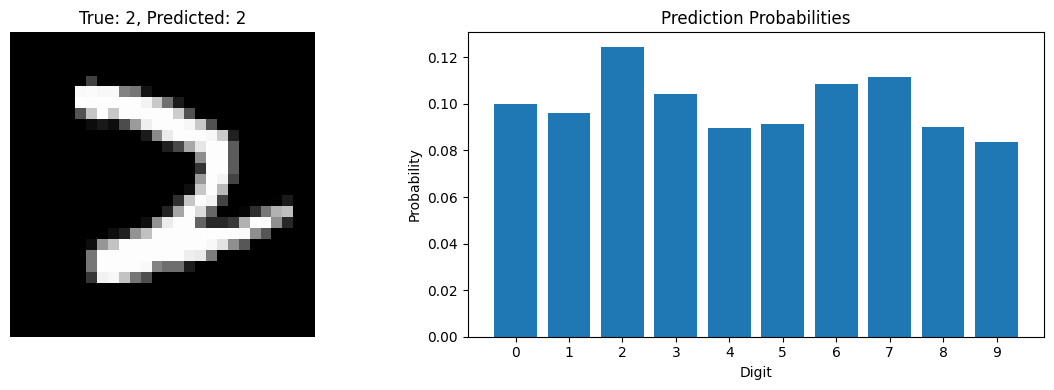


Sample 8045:
  True Label: 2
  Predicted: 2
  Confidence: 12.45%


Total Errors: 3715 out of 14000
Error Rate: 26.54%


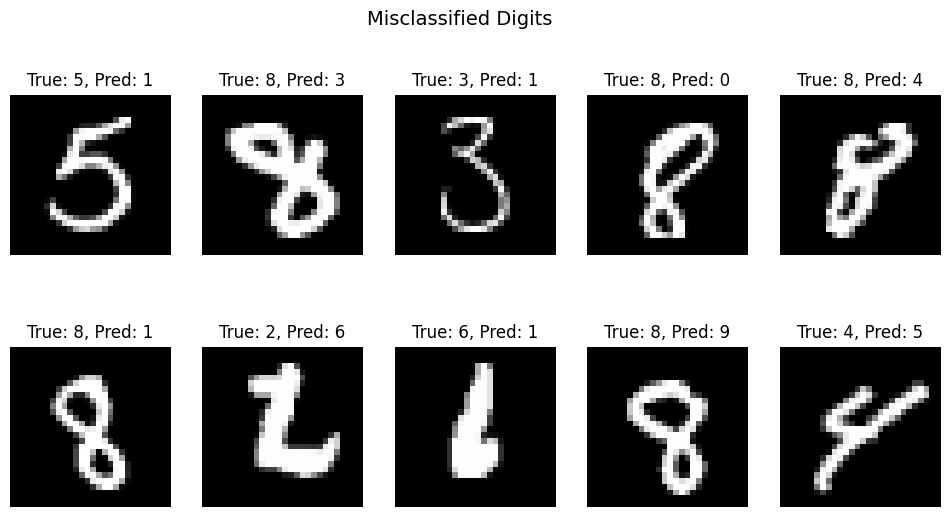

Misclassified examples saved!

ANALYSIS COMPLETE!


In [23]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred_test))

# Step 9: Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# Step 10: Prediction on New Samples
def predict_digit(model, scaler, image_index):
    """Single image ka prediction with visualization"""
    sample = X_test.iloc[image_index].values.reshape(1, -1)
    sample_scaled = scaler.transform(sample)

    prediction = model.predict(sample_scaled)[0]
    probabilities = model.predict_proba(sample_scaled)[0]

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Image display
    ax1.imshow(X_test.iloc[image_index].values.reshape(28, 28), cmap='gray')
    ax1.set_title(f'True: {y_test.iloc[image_index]}, Predicted: {prediction}')
    ax1.axis('off')

    # Probability distribution
    ax2.bar(range(10), probabilities)
    ax2.set_xlabel('Digit')
    ax2.set_ylabel('Probability')
    ax2.set_title('Prediction Probabilities')
    ax2.set_xticks(range(10))

    plt.tight_layout()
    plt.show()

    return prediction, probabilities

# Test karte hain 5 random samples par
print("\n" + "="*60)
print("SAMPLE PREDICTIONS")
print("="*60)
np.random.seed(42)
test_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in test_indices:
    pred, probs = predict_digit(model, scaler, idx)
    print(f"\nSample {idx}:")
    print(f"  True Label: {y_test.iloc[idx]}")
    print(f"  Predicted: {pred}")
    print(f"  Confidence: {probs[int(pred)]*100:.2f}%") # Changed pred to int(pred) for indexing

# Step 11: Error Analysis
errors = y_test != y_pred_test
error_indices = np.where(errors)[0]

print(f"\n\nTotal Errors: {len(error_indices)} out of {len(y_test)}")
print(f"Error Rate: {len(error_indices)/len(y_test)*100:.2f}%")

# Misclassified images dekhna
if len(error_indices) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()

    for i, idx in enumerate(error_indices[:10]):
        image = X_test.iloc[idx].values.reshape(28, 28)
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f'True: {y_test.iloc[idx]}, Pred: {y_pred_test[idx]}')
        axes[i].axis('off')

    plt.suptitle('Misclassified Digits', fontsize=14)
    plt.show()
    print("Misclassified examples saved!")

print("\n" + "="*60)
print("ANALYSIS COMPLETE!")
print("="*60)